In [ ]:
# Remove conflicting packages
!pip uninstall -y jax jaxlib ml-dtypes

# Install stable versions
!pip install tensorflow==2.16.2 keras==3.3.3

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: ml-dtypes 0.3.2
Uninstalling ml-dtypes-0.3.2:
  Successfully uninstalled ml-dtypes-0.3.2
  Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
orbax-checkpoint 0.11.33 requires jax>=0.6.0, which is not installed.
flax 0.11.2 requires jax>=0.6.0, which is not installed.
tf-keras 2.19.0 requires tensorflow<

In [ ]:
import tensorflow as tf
import numpy as np

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.16.2
NumPy: 1.26.4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATA_PATH = "/content/drive/MyDrive/energy_data/"

In [ ]:
electricity = pd.read_csv(DATA_PATH + "electricity.csv")
gas = pd.read_csv(DATA_PATH + "gas.csv")
water = pd.read_csv(DATA_PATH + "water.csv")
#steam = pd.read_csv(DATA_PATH + "steam.csv")
#hotwater = pd.read_csv(DATA_PATH + "hotwater.csv")
#chilled = pd.read_csv(DATA_PATH + "chilledwater.csv")
#solar = pd.read_csv(DATA_PATH + "solar.csv")
#irrigation = pd.read_csv(DATA_PATH + "irrigation.csv")

weather = pd.read_csv(DATA_PATH + "weather.csv")
metadata = pd.read_csv(DATA_PATH + "metadata.csv")

In [ ]:
print("Electricity:")
display(electricity.head())

print("Metadata:")
display(metadata.head())

print("Weather:")
display(weather.head())

Electricity:


,timestamp,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie,Panther_education_Teofila,Panther_education_Jerome,Panther_retail_Felix,Panther_parking_Asia,Panther_education_Misty,...,Cockatoo_public_Caleb,Cockatoo_education_Tyler,Cockatoo_public_Shad,Mouse_health_Buddy,Mouse_health_Modesto,Mouse_lodging_Vicente,Mouse_health_Justin,Mouse_health_Ileana,Mouse_health_Estela,Mouse_science_Micheal
0,2016-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,123.200,727.575,69.200,8.8224,370.0870,10.0,282.9965,26.0,135.0,168.2243
1,2016-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,126.475,731.200,66.275,17.6449,737.8260,30.0,574.9265,51.0,265.0,336.4486
2,2016-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,127.825,724.675,64.675,17.6449,729.9255,30.0,570.2780,50.0,272.0,336.4486
3,2016-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,130.475,737.375,65.875,17.6449,722.2620,20.0,561.1470,52.0,276.0,336.4486
4,2016-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,129.675,721.150,66.275,17.6449,719.1665,30.0,564.3695,50.0,280.0,336.4486


Metadata:


,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
0,Panther_lodging_Dean,Panther,NaN,0.0,Lodging/residential,Residence Hall,508.8,5477.0,28.517689,-81.379039,...,1989.0,NaN,NaN,NaN,NaN,271,NaN,NaN,NaN,NaN
1,Panther_lodging_Shelia,Panther,NaN,0.0,Lodging/residential,Residence Hall,929.0,10000.0,28.517689,-81.379039,...,1992.0,NaN,NaN,NaN,NaN,62,NaN,NaN,NaN,NaN
2,Panther_lodging_Ricky,Panther,NaN,0.0,Lodging/residential,Residence Hall,483.1,5200.0,28.517689,-81.379039,...,2016.0,NaN,NaN,NaN,NaN,534,NaN,NaN,NaN,NaN
3,Panther_education_Rosalie,Panther,0.0,0.0,Education,Research,690.5,7432.0,28.517689,-81.379039,...,2008.0,NaN,NaN,NaN,NaN,276,NaN,NaN,NaN,NaN
4,Panther_education_Misty,Panther,1.0,0.0,Education,Research,252.7,2720.0,28.517689,-81.379039,...,2004.0,NaN,NaN,NaN,NaN,375,NaN,NaN,NaN,NaN


Weather:


,timestamp,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed
0,2016-01-01 00:00:00,Panther,19.4,NaN,19.4,0.0,NaN,NaN,0.0,0.0
1,2016-01-01 01:00:00,Panther,21.1,6.0,21.1,-1.0,NaN,1019.4,0.0,0.0
2,2016-01-01 02:00:00,Panther,21.1,NaN,21.1,0.0,NaN,1018.8,210.0,1.5
3,2016-01-01 03:00:00,Panther,20.6,NaN,20.0,0.0,NaN,1018.1,0.0,0.0
4,2016-01-01 04:00:00,Panther,21.1,NaN,20.6,0.0,NaN,1019.0,290.0,1.5


In [ ]:
weather.rename(columns={
    "airTemperature": "air_temperature",
    "cloudCoverage": "cloud_coverage",
    "dewTemperature": "dew_temperature"
}, inplace=True)

In [ ]:
# Reduce Data Size
electricity = electricity.iloc[:1000]
gas = gas.iloc[:1000]
water = water.iloc[:1000]

In [ ]:
## Find Common Buildings
elec_cols = set(electricity.columns[1:])
gas_cols = set(gas.columns[1:])
water_cols = set(water.columns[1:])

common_cols = list(elec_cols & gas_cols & water_cols)

print("Common buildings:", common_cols)

Common buildings: ['Bobcat_lodging_Darin', 'Panther_office_Kristen', 'Panther_lodging_Edison', 'Panther_lodging_Alita', 'Bobcat_education_Alissa', 'Bobcat_office_Nikita', 'Wolf_education_Bobby', 'Panther_office_Patti', 'Panther_education_Mohammad', 'Bobcat_education_Seth', 'Wolf_office_Rochelle', 'Panther_education_Alecia', 'Panther_office_Graham', 'Panther_office_Lauretta', 'Panther_education_Ivan', 'Panther_education_Jerome', 'Wolf_education_Cody', 'Wolf_education_Roderick', 'Panther_lodging_Sonja', 'Panther_education_Hugh', 'Panther_education_Gina', 'Panther_office_Shauna', 'Wolf_retail_Toshia', 'Panther_other_Tyrone', 'Panther_other_Lucina', 'Wolf_education_Dorris', 'Bobcat_assembly_Franklin', 'Panther_lodging_Anastasia', 'Bobcat_lodging_Melaine', 'Wolf_education_Loren', 'Panther_education_Edna', 'Wolf_education_Ursula', 'Panther_other_Bettie', 'Bobcat_office_Justine', 'Wolf_assembly_Sallie', 'Panther_lodging_Blaine', 'Panther_education_Teofila', 'Panther_education_Sophia', 'Panthe

In [ ]:
### Use Only 3 Common Buildings
common_cols = [
    'Panther_lodging_Hattie',
    'Panther_education_Jerome',
    'Panther_education_Teofila'
]

electricity = electricity[["timestamp"] + common_cols]
gas = gas[["timestamp"] + common_cols]
water = water[["timestamp"] + common_cols]

In [ ]:
### Convert Wide - long
def convert_long(df, name):
    df = df.drop(columns=["meter"], errors="ignore")

    df = df.melt(
        id_vars=["timestamp"],
        var_name="building_id",
        value_name="meter_reading"
    )

    df["meter"] = name
    return df

electricity = convert_long(electricity, "electricity")
gas = convert_long(gas, "gas")
water = convert_long(water, "water")

In [ ]:
# Combine datasets
df_all = pd.concat([electricity, gas, water], ignore_index=True)

print("Shape after combine:", df_all.shape)
display(df_all.head())

Shape after combine: (9000, 4)


,timestamp,building_id,meter_reading,meter
0,2016-01-01 00:00:00,Panther_lodging_Hattie,0.0,electricity
1,2016-01-01 01:00:00,Panther_lodging_Hattie,0.0,electricity
2,2016-01-01 02:00:00,Panther_lodging_Hattie,0.0,electricity
3,2016-01-01 03:00:00,Panther_lodging_Hattie,0.0,electricity
4,2016-01-01 04:00:00,Panther_lodging_Hattie,0.0,electricity


In [ ]:
## Convert Data Types
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

df_all["building_id"] = df_all["building_id"].astype(str)
metadata["building_id"] = metadata["building_id"].astype(str)

In [ ]:
## Merge metadata and weather
df_all = df_all.merge(metadata, on="building_id", how="left")

df_all = df_all.merge(
    weather,
    on=["site_id", "timestamp"],
    how="left"
)

In [ ]:
## Data cleaning
df_all = df_all.fillna(method="ffill").fillna(method="bfill")
df_all = df_all[df_all["meter_reading"] >= 0]

/tmp/ipykernel_38793/3588914317.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_all = df_all.fillna(method="ffill").fillna(method="bfill")
/tmp/ipykernel_38793/3588914317.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all = df_all.fillna(method="ffill").fillna(method="bfill")


In [ ]:
print(df_all.isnull().sum())

timestamp                0
building_id              0
meter_reading            0
meter                    0
site_id                  0
building_id_kaggle       0
site_id_kaggle           0
primaryspaceusage        0
sub_primaryspaceusage    0
sqm                      0
sqft                     0
lat                      0
lng                      0
timezone                 0
electricity              0
chilledwater             0
water                    0
gas                      0
yearbuilt                0
eui                      0
leed_level               0
air_temperature          0
cloud_coverage           0
dew_temperature          0
precipDepth1HR           0
precipDepth6HR           0
seaLvlPressure           0
windDirection            0
windSpeed                0
dtype: int64


In [ ]:
drop_cols = [
    "hotwater", "steam", "irrigation", "solar",
    "industry", "subindustry", "heatingtype",
    "date_opened", "numberoffloors", "occupants",
    "energystarscore", "site_eui", "source_eui",
    "rating"
]

df_all = df_all.drop(columns=drop_cols, errors="ignore")

In [ ]:
## Feature Engineering
df_all["hour"] = df_all["timestamp"].dt.hour
df_all["weekday"] = df_all["timestamp"].dt.weekday
df_all["month"] = df_all["timestamp"].dt.month

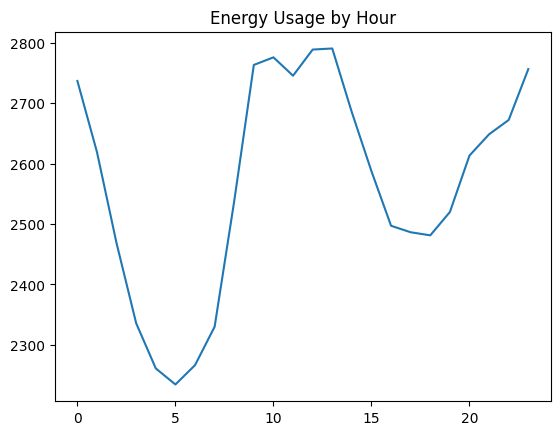

In [ ]:
## Hourly Pattern
hourly = df_all.groupby("hour")["meter_reading"].mean()

plt.figure()
plt.plot(hourly.index, hourly.values)
plt.title("Energy Usage by Hour")
plt.show()

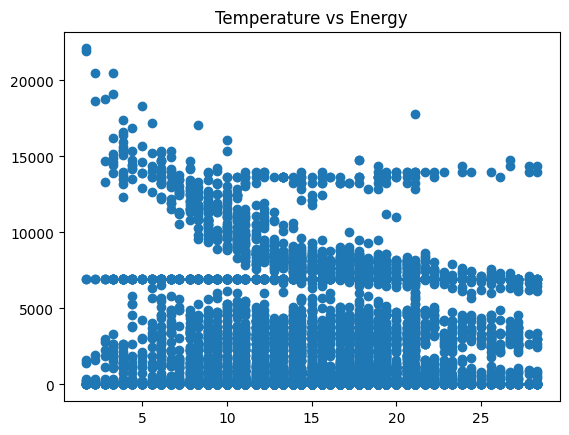

In [ ]:
## Temperature vs Energy
plt.scatter(df_all["air_temperature"], df_all["meter_reading"])
plt.title("Temperature vs Energy")
plt.show()

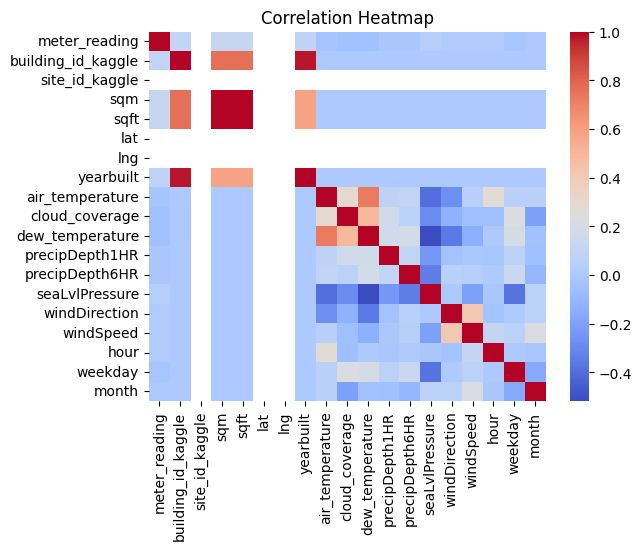

In [ ]:
numeric_df = df_all.select_dtypes(include=["number"])

plt.figure()
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

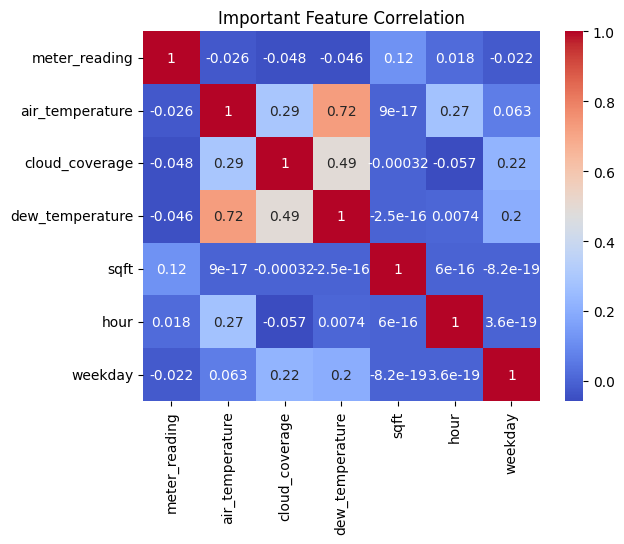

In [ ]:
cols = [
    "meter_reading",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "sqft",
    "hour",
    "weekday"
]

plt.figure()
sns.heatmap(df_all[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Important Feature Correlation")
plt.show()

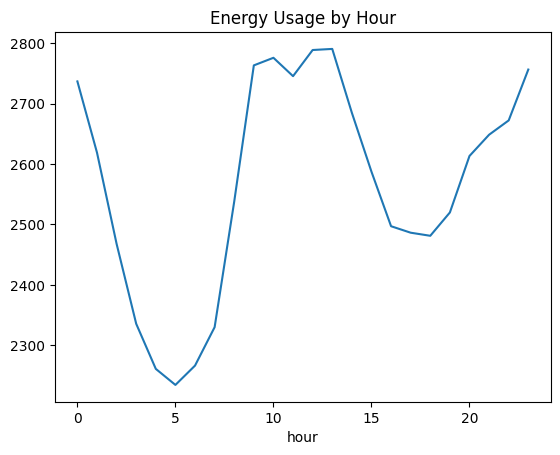

In [ ]:
df_all.groupby("hour")["meter_reading"].mean().plot()
plt.title("Energy Usage by Hour")
plt.show()

In [ ]:
df_all = pd.get_dummies(df_all, columns=["meter"])

In [ ]:
print(df_all.columns)

Index(['timestamp', 'building_id', 'meter_reading', 'site_id',
       'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage',
       'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone',
       'electricity', 'chilledwater', 'water', 'gas', 'yearbuilt', 'eui',
       'leed_level', 'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precipDepth1HR', 'precipDepth6HR', 'seaLvlPressure', 'windDirection',
       'windSpeed', 'hour', 'weekday', 'month', 'meter_electricity',
       'meter_gas', 'meter_water'],
      dtype='object')


In [ ]:
### Random Forest Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = [
    "air_temperature",
    "hour",
    "weekday",
    "sqft",
    "meter_gas",
    "meter_water"
]

df_all = df_all.dropna()

X = df_all[features]
y = df_all["meter_reading"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=50)
model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = np.sqrt(((y_test - pred) ** 2).mean())
print("RMSE:", rmse)

RMSE: 1225.1896201335107


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, pred)

# R2 Score
r2 = r2_score(y_test, pred)

# MAPE (Mean Absolute Percentage Error)
mape = (abs((y_test - pred) / y_test).mean()) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("MAPE (%):", mape)

RMSE: 1225.1896201335107
MAE: 459.8651373450234
R2 Score: 0.8859907891258324
MAPE (%): inf


In [ ]:
### LSTM model
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

In [ ]:
## Create sequences
def create_sequences(X, y, time_steps=24):
    X_seq, y_seq = [], []

    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled)

In [ ]:
## split
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [ ]:
## Build LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

model.fit(X_train, y_train, epochs=25, batch_size=32)

Epoch 1/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0132
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0059
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0054
Epoch 4/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0054
Epoch 5/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0047
Epoch 6/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0053
Epoch 7/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0049
Epoch 8/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0044
Epoch 9/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0040
Epoch 10/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0039
Epoch 11/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0038
Epoch 12/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0038
Epoch 13/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0040
Epoch 14/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0036
Epoch 15/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s

In [ ]:
pred = model.predict(X_test)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


In [ ]:
pred = scaler_y.inverse_transform(pred)
y_test_actual = scaler_y.inverse_transform(y_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Avoid division by zero in MAPE
y_test_actual_safe = np.where(y_test_actual == 0, 1, y_test_actual)

rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
mae = mean_absolute_error(y_test_actual, pred)
r2 = r2_score(y_test_actual, pred)
mape = np.mean(np.abs((y_test_actual - pred) / y_test_actual_safe)) * 100

print(" LSTM Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

 LSTM Performance:
RMSE: 812.12
MAE: 614.43
R2 Score: 0.1099
MAPE: 16516.81%


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train.reshape(X_train.shape[0], -1), y_train)

rf_pred = rf_model.predict(X_test.reshape(X_test.shape[0], -1))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
rf_pred = scaler_y.inverse_transform(rf_pred.reshape(-1,1))

rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))
rf_mae = mean_absolute_error(y_test_actual, rf_pred)
rf_r2 = r2_score(y_test_actual, rf_pred)
rf_mape = np.mean(np.abs((y_test_actual - rf_pred) / y_test_actual_safe)) * 100

print("\n Random Forest Performance:")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE: {rf_mae:.2f}")
print(f"R2 Score: {rf_r2:.4f}")
print(f"MAPE: {rf_mape:.2f}%")


 Random Forest Performance:
RMSE: 844.20
MAE: 437.95
R2 Score: 0.0382
MAPE: 3065.39%


In [ ]:
## Comparison table
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "LSTM"],
    "RMSE": [rf_rmse, rmse],
    "MAE": [rf_mae, mae],
    "R2 Score": [rf_r2, r2],
    "MAPE (%)": [rf_mape, mape]
})

print("\n Model Comparison:")
print(comparison)


 Model Comparison:
           Model        RMSE         MAE  R2 Score      MAPE (%)
0  Random Forest  844.197277  437.954022  0.038212   3065.390266
1           LSTM  812.116800  614.427310  0.109921  16516.814502


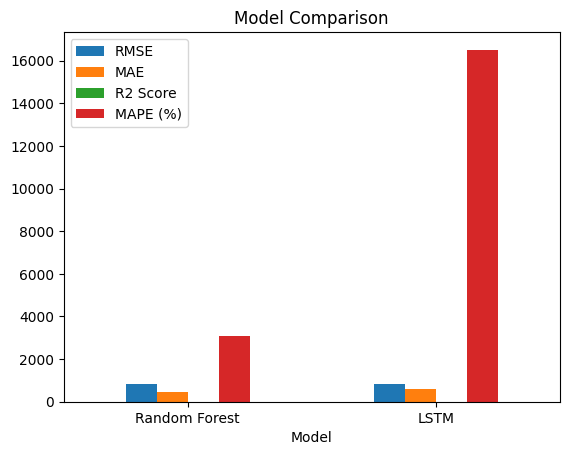

In [ ]:
comparison.set_index("Model").plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [ ]:
## FUTURE PREDICTION
last_sequence = X_test[-1]   # last test sequence
last_sequence = last_sequence.reshape(1, last_sequence.shape[0], last_sequence.shape[1])

In [ ]:
## Predict future

future_predictions = []
current_seq = last_sequence.copy()

for _ in range(30):

    pred_val = model.predict(current_seq)[0][0]
    future_predictions.append(pred_val)

    next_step = current_seq[0, -1].copy()
    next_step[0] = pred_val  # update lag

    current_seq = np.append(current_seq[:,1:,:], [[next_step]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━

In [ ]:
## Inverse Scale
future_predictions = scaler_y.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

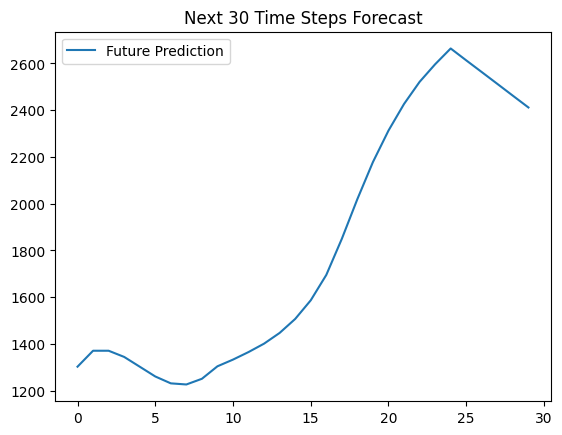

In [ ]:
plt.figure()
plt.plot(future_predictions, label="Future Prediction")
plt.title("Next 30 Time Steps Forecast")
plt.legend()
plt.show()

In [ ]:
future_dates = pd.date_range(
    start=df_all["timestamp"].iloc[-1],
    periods=30,
    freq="H"  # change to "D" if daily
)

future_df = pd.DataFrame({
    "timestamp": future_dates,
    "prediction": future_predictions.flatten()
})

print(future_df)

             timestamp   prediction
0  2016-02-11 15:00:00  1303.021362
1  2016-02-11 16:00:00  1371.215698
2  2016-02-11 17:00:00  1371.218506
3  2016-02-11 18:00:00  1344.770264
4  2016-02-11 19:00:00  1303.036011
5  2016-02-11 20:00:00  1261.198608
6  2016-02-11 21:00:00  1231.748657
7  2016-02-11 22:00:00  1226.962402
8  2016-02-11 23:00:00  1251.305176
9  2016-02-12 00:00:00  1304.736206
10 2016-02-12 01:00:00  1333.333008
11 2016-02-12 02:00:00  1365.654907
12 2016-02-12 03:00:00  1401.640015
13 2016-02-12 04:00:00  1447.435791
14 2016-02-12 05:00:00  1507.200195
15 2016-02-12 06:00:00  1586.879028
16 2016-02-12 07:00:00  1695.335205
17 2016-02-12 08:00:00  1849.897461
18 2016-02-12 09:00:00  2019.842651
19 2016-02-12 10:00:00  2178.085449
20 2016-02-12 11:00:00  2312.553711
21 2016-02-12 12:00:00  2426.313721
22 2016-02-12 13:00:00  2520.798096
23 2016-02-12 14:00:00  2596.134277
24 2016-02-12 15:00:00  2663.582520
25 2016-02-12 16:00:00  2612.763672
26 2016-02-12 17:00:00  2562

/tmp/ipykernel_38793/2715180248.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(


In [ ]:
model.save("energy_lstm_model.h5")

In [ ]:
import pickle

# Save scalers
with open("scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)

with open("scaler_y.pkl", "wb") as f:
    pickle.dump(scaler_y, f)

In [ ]:
features = [
    "air_temperature",
    "hour",
    "weekday",
    "sqft",
    "meter_gas",
    "meter_water",
    "lag_1",
    "lag_24",
    "rolling_mean_3"
]

with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

In [ ]:
df_all.tail(100).to_csv("sample_data.csv", index=False)

In [ ]:
from google.colab import files

files.download("energy_lstm_model.h5")
files.download("scaler_X.pkl")
files.download("scaler_y.pkl")
files.download("features.pkl")
files.download("sample_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>